<a href="https://colab.research.google.com/github/israelSotelo/ADAS-AI-Validation-Portfolio/blob/main/ADAS-AI-Validation-Portfolio/tree/main/Technical-Projects/notebooks/Portfolio_AMD_Detection_VGG19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Libraries

In [ ]:
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import SeparableConv2D
from keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.regularizers import l1, l2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2 as cv
import os
import glob
import numpy as np
from sklearn.utils import shuffle
import random
import seaborn as sns
%matplotlib inline

## Install kaggle to directly download the dataset

In [ ]:
# plot diagnostic learning curves
def summarize_diagnostics(history):
	# plot loss
	pyplot.subplot(211)
	pyplot.title('Cross Entropy Loss')
	pyplot.plot(history.history['loss'], color='blue', label='train')
	pyplot.plot(history.history['val_loss'], color='orange', label='test')
	# plot accuracy
	pyplot.subplot(212)
	pyplot.title('Classification Accuracy')
	pyplot.plot(history.history['accuracy'], color='blue', label='train')
	pyplot.plot(history.history['val_accuracy'], color='orange', label='test')
	# save plot to file
	filename = sys.argv[0].split('/')[-1]
	pyplot.show()
	pyplot.savefig(filename + '_plot.png')
	pyplot.close()

## Dowload dataset

In [ ]:
! pip install kaggle

In [ ]:
# Make a directory named “.kaggle”
! mkdir ~/.kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
# Copy the “kaggle.json” into this new directory
! cp ./kaggle.json ~/.kaggle/

In [ ]:
# Allocate the required permission for this file.
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# download the dataser
! kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
 95% 1.55G/1.62G [00:16<00:02, 38.7MB/s]
100% 1.62G/1.62G [00:16<00:00, 108MB/s] 


### if you don't have a kaggle acount and can't generate the kaggle.json you can download the dataset directly from here
https://academictorrents.com/details/cf3b8d5ecdd4284eb9b3a80fcfe9b1d621548f72

In [ ]:
# descomprimir el dataset de odir-5k
! unzip '/content/ocular-disease-recognition-odir5k.zip'

Streaming output truncated to the last 5000 lines.
  inflating: preprocessed_images/2179_left.jpg  
  inflating: preprocessed_images/2179_right.jpg  
  inflating: preprocessed_images/217_left.jpg  
  inflating: preprocessed_images/217_right.jpg  
  inflating: preprocessed_images/2180_left.jpg  
  inflating: preprocessed_images/2180_right.jpg  
  inflating: preprocessed_images/2181_left.jpg  
  inflating: preprocessed_images/2181_right.jpg  
  inflating: preprocessed_images/2182_left.jpg  
  inflating: preprocessed_images/2182_right.jpg  
  inflating: preprocessed_images/2183_left.jpg  
  inflating: preprocessed_images/2183_right.jpg  
  inflating: preprocessed_images/2184_left.jpg  
  inflating: preprocessed_images/2184_right.jpg  
  inflating: preprocessed_images/2185_left.jpg  
  inflating: preprocessed_images/2185_right.jpg  
  inflating: preprocessed_images/2187_left.jpg  
  inflating: preprocessed_images/2187_right.jpg  
  inflating: preprocessed_images/2189_left.jpg  
  inflating

## Dataset analysis and Preparation

## Dataset Relevant Information:

Type: Dataset


Abstract:
We collected a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords from doctors (in short, ODIR-5K).

This dataset is ‘‘real-life’’ set of patient information collected by Shanggong Medical Technology Co., Ltd. from different hospitals/medical centers in China. In these institutions, fundus images are captured by various cameras in the market, such as Canon, Zeiss and Kowa, resulting into varied image resolutions. Patient identifying information will be removed. Annotations are labeled by trained human readers with quality control management.

 They classify patient into eight labels including normal (N), diabetes (D), glaucoma (G), cataract (C), AGE MACULAR DEGENERATION (A), hypertension (H), myopia (M) and other diseases/abnormalities (O) based on both eye images and additionally patient age. The publishing of this dataset follows the ethical and privacy rules of China. Table 1 shows one record from ODIR-5K dataset.

## Load the ODIR-5k dataset

In [ ]:
# Data columns name
data_columns = ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus',
                'Right-Fundus', 'Left-Diagnostic Keywords',
                'Right-Diagnostic Keywords', 'N', 'D', 'G',
                'C', 'A',	'H', 'M', 'O']
# Loading the data
dataset = pd.read_excel(r'/content/ODIR-5K/ODIR-5K/data.xlsx', index_col='ID', na_values= '?')
dataset.head(15)

,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
ID,,,,,,,,,,,,,,
0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1
5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
6,60,Male,6_left.jpg,6_right.jpg,macular epiretinal membrane,moderate non proliferative retinopathy，epireti...,0,1,0,0,0,0,0,1
7,60,Female,7_left.jpg,7_right.jpg,drusen,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1
8,59,Male,8_left.jpg,8_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0


### Checking the data base integrity

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3500 entries, 0 to 4784
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Patient Age                3500 non-null   int64 
 1   Patient Sex                3500 non-null   object
 2   Left-Fundus                3500 non-null   object
 3   Right-Fundus               3500 non-null   object
 4   Left-Diagnostic Keywords   3500 non-null   object
 5   Right-Diagnostic Keywords  3500 non-null   object
 6   N                          3500 non-null   int64 
 7   D                          3500 non-null   int64 
 8   G                          3500 non-null   int64 
 9   C                          3500 non-null   int64 
 10  A                          3500 non-null   int64 
 11  H                          3500 non-null   int64 
 12  M                          3500 non-null   int64 
 13  O                          3500 non-null   int64 
dtypes: int64(9), 

In [ ]:
print("Shape: ", dataset.shape)
print("\nCount: \n", dataset.count())

Shape:  (3500, 14)

Count: 
 Patient Age                  3500
Patient Sex                  3500
Left-Fundus                  3500
Right-Fundus                 3500
Left-Diagnostic Keywords     3500
Right-Diagnostic Keywords    3500
N                            3500
D                            3500
G                            3500
C                            3500
A                            3500
H                            3500
M                            3500
O                            3500
dtype: int64


In [ ]:
dataset.describe()

,Patient Age,N,D,G,C,A,H,M,O
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,57.854000,0.325714,0.322286,0.061429,0.060571,0.046857,0.029429,0.049714,0.279714
std,11.724064,0.468708,0.467419,0.240149,0.238577,0.211363,0.169029,0.217385,0.448923
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,66.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,91.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Let's check which images have the AMD flag positive and which images have the eye diagnosys associated clearly stating either AMD or normal


In [ ]:
dataset[dataset['A']==1].head(15)

,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
ID,,,,,,,,,,,,,,
43,35,Male,43_left.jpg,43_right.jpg,wet age-related macular degeneration,dry age-related macular degeneration，glaucoma,0,0,1,0,1,0,0,0
48,69,Female,48_left.jpg,48_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
53,65,Female,53_left.jpg,53_right.jpg,wet age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
55,62,Male,55_left.jpg,55_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
71,56,Female,71_left.jpg,71_right.jpg,diabetic retinopathy,wet age-related macular degeneration，diabetic ...,0,1,0,0,1,0,0,0
102,73,Female,102_left.jpg,102_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
126,66,Male,126_left.jpg,126_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
136,75,Female,136_left.jpg,136_right.jpg,wet age-related macular degeneration,refractive media opacity,0,0,0,0,1,0,0,1
152,55,Male,152_left.jpg,152_right.jpg,wet age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0


In [ ]:
print(dataset.loc[(dataset.A==1)].shape)
print(dataset.loc[dataset.A==0].shape)

(164, 14)
(3336, 14)


In [ ]:
# Left eye
dataset.loc[(dataset.A==0)]['Left-Diagnostic Keywords'].value_counts()

,count
Left-Diagnostic Keywords,
normal fundus,1420
moderate non proliferative retinopathy,365
mild nonproliferative retinopathy,220
cataract,135
pathological myopia,111
...,...
laser spot，cataract,1
lens dust，lens dust,1
post retinal laser surgery，proliferative diabetic retinopathy,1


In [ ]:
# Right eye
dataset.loc[(dataset.A==0)]['Right-Diagnostic Keywords'].value_counts()

,count
Right-Diagnostic Keywords,
normal fundus,1374
moderate non proliferative retinopathy,379
mild nonproliferative retinopathy,240
cataract,127
pathological myopia,116
...,...
cataract，laser spot,1
hypertensive retinopathy，diabetic retinopathy,1
post retinal laser surgery，proliferative diabetic retinopathy，cataract,1


In [ ]:
def has_AMD_mentioned(text):
    if 'macular degeneration' in text:
        return 1
    else:
        return 0

In [ ]:
# Creating a label for AMD
#
dataset['re_AMD'] = dataset['Right-Diagnostic Keywords'].apply(lambda x: has_AMD_mentioned(x))

In [ ]:
# Creating a label for AMD
#
dataset['le_AMD'] = dataset['Left-Diagnostic Keywords'].apply(lambda x: has_AMD_mentioned(x))

In [ ]:
# filtering the picture name from the left eye AMD
AMD_le_list = dataset.loc[(dataset.A==1) & (dataset.le_AMD==1)]['Left-Fundus'].values
# filtering the picture name from the right eye AMD
AMD_re_list = dataset.loc[(dataset.A==1) & (dataset.re_AMD==1)]['Right-Fundus'].values
print('Left eye AMD Count: {} \nRight eye AMD Count: {}'.format(len(AMD_le_list), len(AMD_re_list)))
# filtering the left eye Normal
non_AMD_le_list = dataset.loc[(dataset.A==0) & (dataset['Left-Diagnostic Keywords']=="normal fundus")]['Left-Fundus'].sample(360, random_state=314).values
# filtering the right eye Normal
non_AMD_re_list = dataset.loc[(dataset.A==0) & (dataset['Right-Diagnostic Keywords']=="normal fundus")]['Right-Fundus'].sample(360, random_state=314).values
print('Left eye Normal Count: {} \nRight eye Normal Count: {}'.format(len(non_AMD_le_list), len(non_AMD_re_list)))

Left eye AMD Count: 136 
Right eye AMD Count: 144
Left eye Normal Count: 360 
Right eye Normal Count: 360


In [ ]:
AMD_list = np.concatenate((AMD_le_list, AMD_re_list), axis = 0)
non_AMD_list = np.concatenate((non_AMD_le_list, non_AMD_re_list), axis = 0)
print(len(non_AMD_list), len(AMD_list))

720 280


In [ ]:
AMD_df = pd.DataFrame({'images': AMD_list, 'label': 1})
normal_df = pd.DataFrame({'images': non_AMD_list,  'label': 0})

In [ ]:
AMD_full_df = pd.concat([AMD_df, normal_df])
AMD_full_df =  shuffle(AMD_full_df, random_state=314)


In [ ]:
AMD_full_df.head(10)

,images,label
484,3428_right.jpg,0
277,4068_right.jpg,1
235,2421_left.jpg,0
25,4577_left.jpg,0
108,1854_left.jpg,1
112,84_left.jpg,0
625,2343_right.jpg,0
227,3339_left.jpg,0
509,2769_right.jpg,0
260,1874_right.jpg,1


In [ ]:
AMD_full_df[AMD_full_df['images'] == '84_left.jpg']
filter = AMD_full_df['images'].isin(['84_left.jpg'])
label = AMD_full_df.label[filter == True].iloc[0]
label

np.int64(0)

In [ ]:
dataset[dataset['Right-Fundus'] == '1085_right.jpg']

,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,re_AMD,le_AMD
ID,,,,,,,,,,,,,,,,
1085,32,Male,1085_left.jpg,1085_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0,1,1


In [ ]:
AMD_full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 484 to 240
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   images  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 23.4+ KB


## Create dataset wih AMD labels

In [ ]:
def process_data(AMD_full_df, DATA_FOLDER):
    dataset = []
    labels = []
    image_name = []
    img_height = 224
    img_width = 224
    for img in tqdm(AMD_full_df['images'].tolist()):
        try:
          path = os.path.join(DATA_FOLDER, img)
          filter = AMD_full_df['images'].isin([img])
          label = AMD_full_df.label[filter == True].iloc[0]
          img_ = cv.imread(path)
          img_ = cv.cvtColor(img_, cv.COLOR_BGR2RGB)
          # img_ = cv.resize(img_, (190, 190))
          # img_ = cv.imread(path, cv.COLOR_BGR2RGB)
          img_ = cv.resize(img_, (img_width, img_height))
          dataset.append(np.array(img_))
          labels.append(np.array(label))
          image_name.append(img)
        except Exception as e:
          continue
    return dataset, labels, image_name

In [ ]:
dataset_, labels, image_name = process_data(AMD_full_df, r'/content/preprocessed_images/')


100%|██████████| 1000/1000 [00:02<00:00, 387.34it/s]


In [ ]:
len(dataset_)

999

In [ ]:
len(labels)

999

In [ ]:
def show_images(data, labels, image_name):
    f, ax = plt.subplots(5,5, figsize=(30,30))
    for i in range(len(labels[:25])):
        label = labels[i]
        img_data = data[i]
        img_name = image_name[i]
        if label  == 0:
            str_label='Normal'
        elif label == 1:
            str_label='AMD'
        ax[i//5, i%5].imshow(img_data)
        ax[i//5, i%5].axis('off')
        ax[i//5, i%5].set_title("Photo:{} -- Label: {}".format(img_name, str_label))
    plt.show()



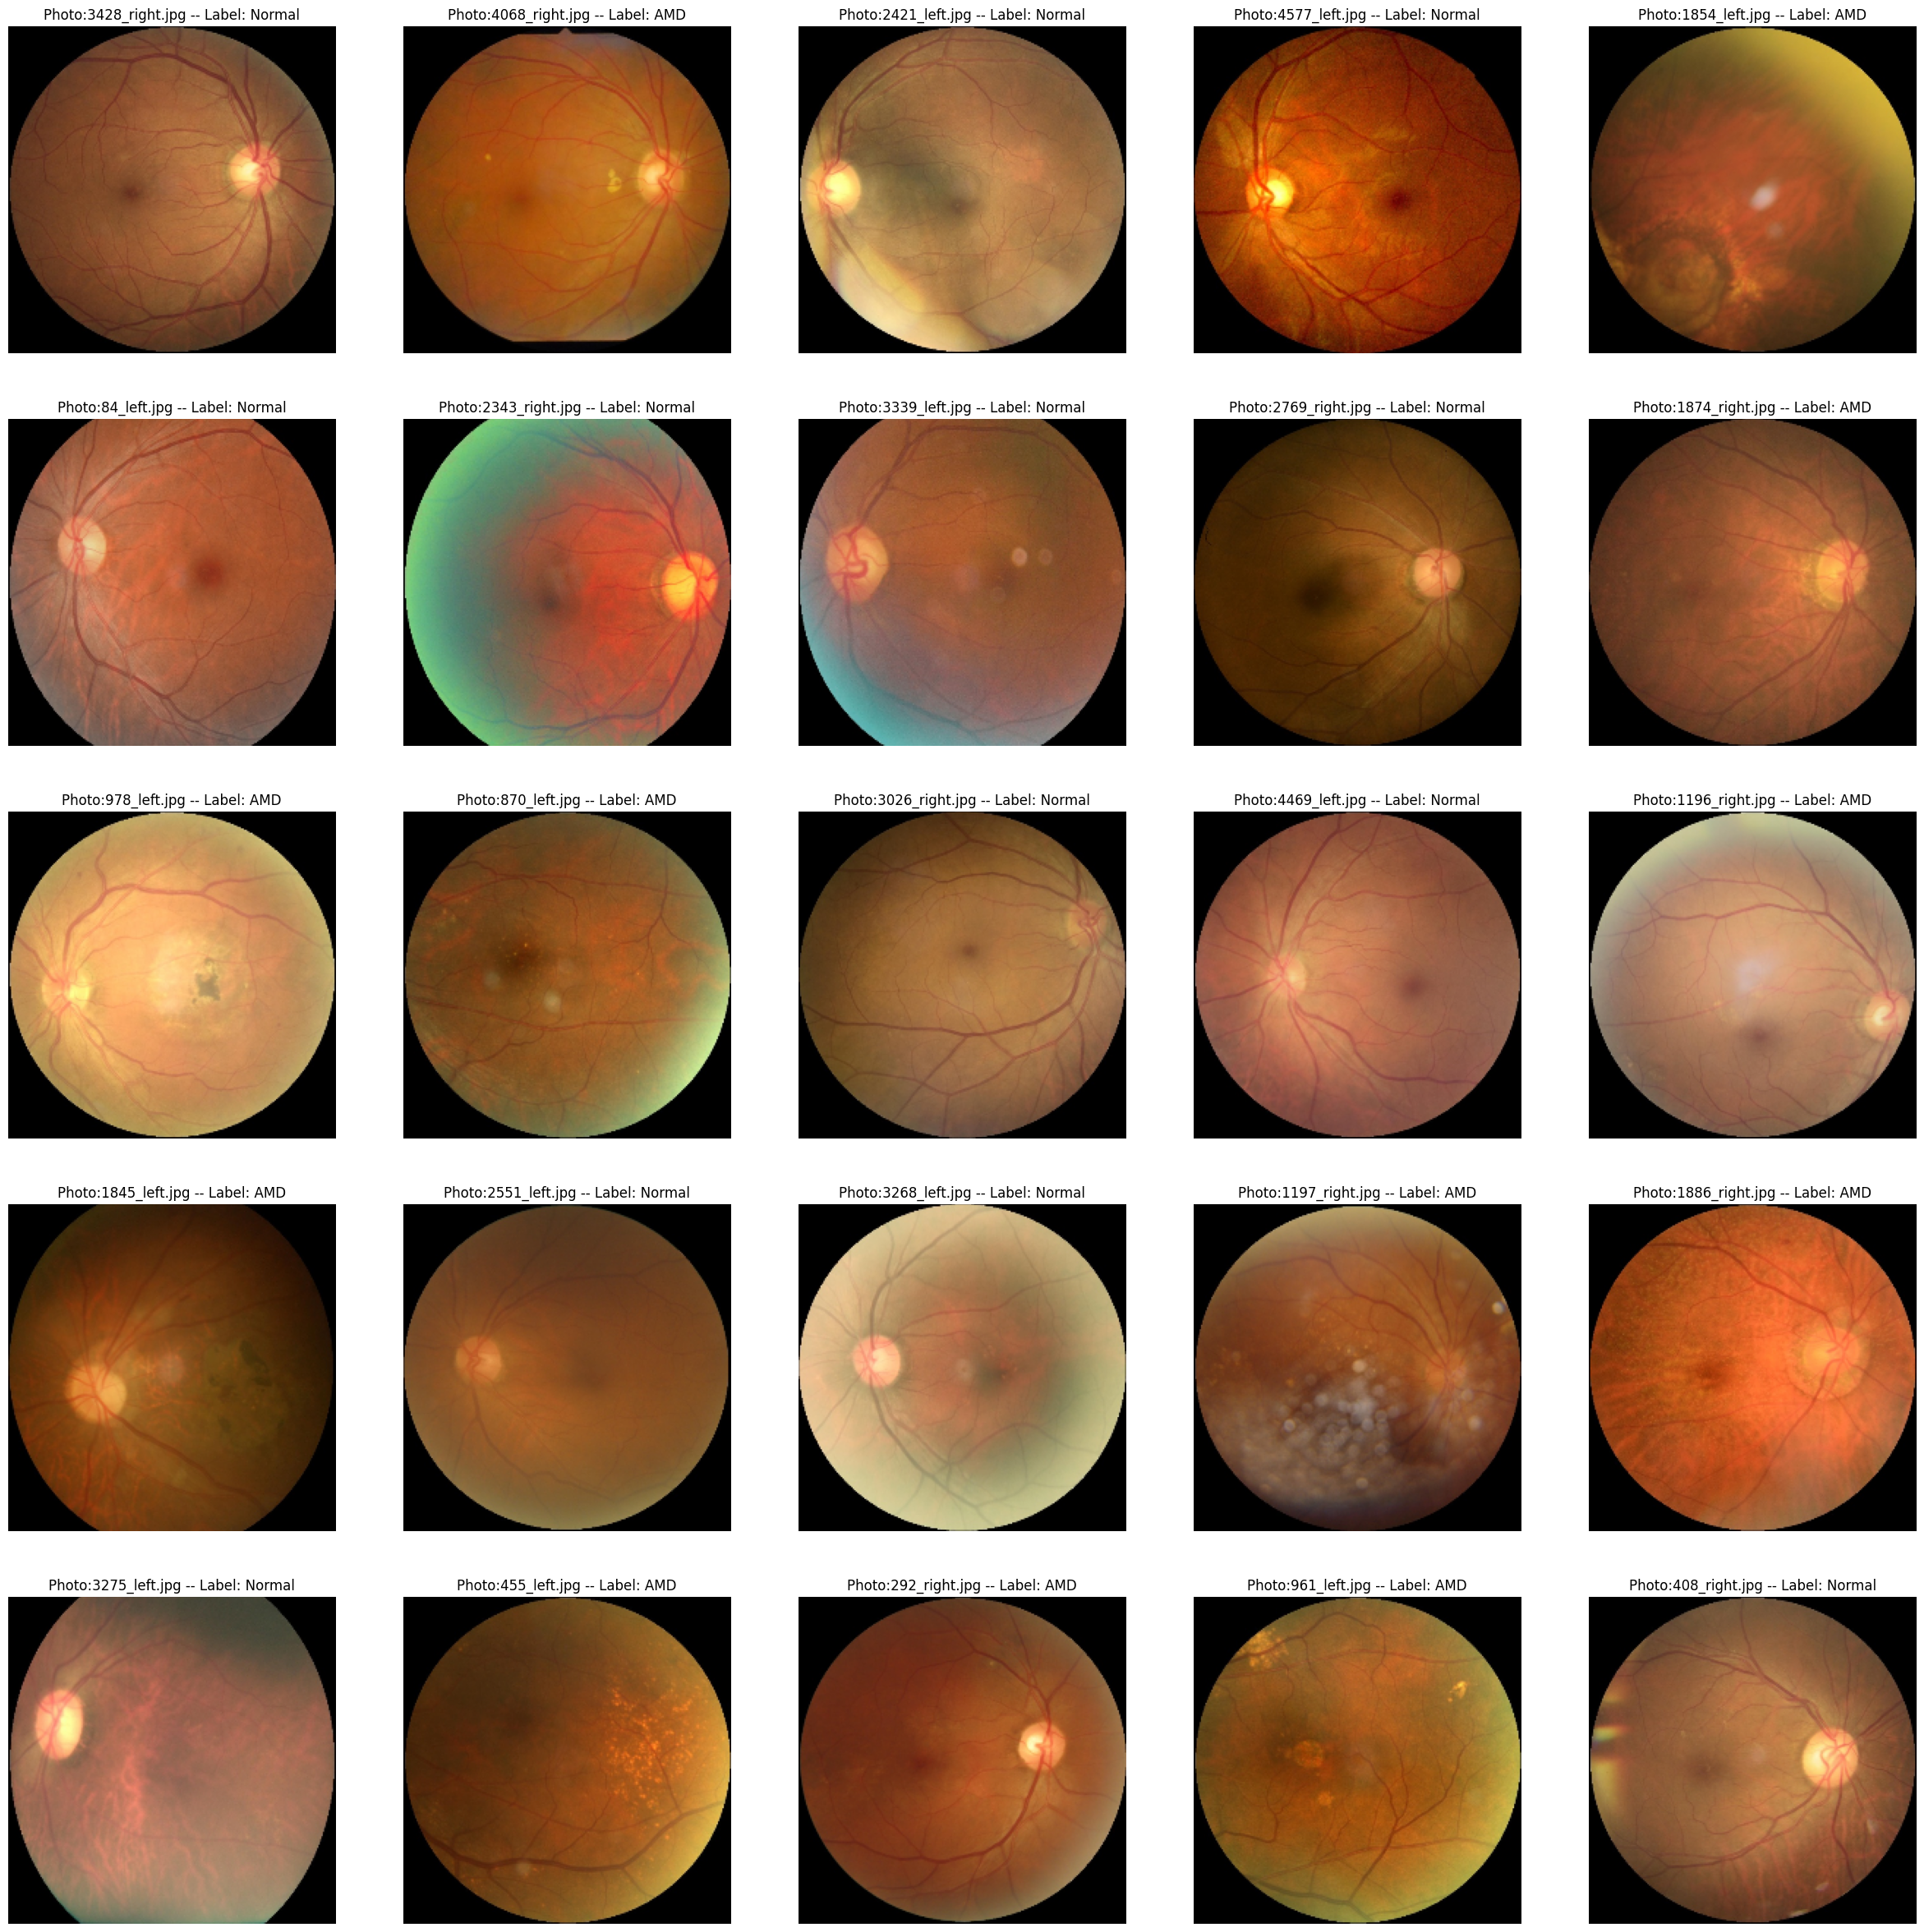

In [ ]:
show_images(dataset_, labels, image_name)

## Split the dataset trainning and validation

In [ ]:
img_height = 224
img_width = 224
X = np.array([i for i in dataset_]).reshape(-1, img_width, img_height, 3)
y = np.array([i for i in labels])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314, shuffle = False)
print('Training Features Shape:', X_train.shape)
print('Training Labels Shape:', y_train.shape)
print('Testing Features Shape:', X_test.shape)
print('Testing Labels Shape:', y_test.shape)

Training Features Shape: (799, 224, 224, 3)
Training Labels Shape: (799,)
Testing Features Shape: (200, 224, 224, 3)
Testing Labels Shape: (200,)


## Data augmentation

In [ ]:
# create data generator
"""train_datagen = ImageDataGenerator(fill_mode='nearest',
																		rescale=1./255,
																		horizontal_flip=True,
																		brightness_range=[0.6,1.2],
																		data_format = "channels_last")"""

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.6, 1.2],
    fill_mode='nearest',
		data_format = "channels_last"
)

test_datagen = ImageDataGenerator(rescale=1./255, data_format = "channels_last")

# prepare iterator
train_generator = train_datagen.flow(X_train, y_train, batch_size=32, seed=314, shuffle=True)
validation_generator = test_datagen.flow(X_test, y_test, batch_size=32, seed=314, shuffle=True)

In [ ]:
train_generator.batch_size

32

In [ ]:
validation_generator.batch_size

32

## Data aumentation preview

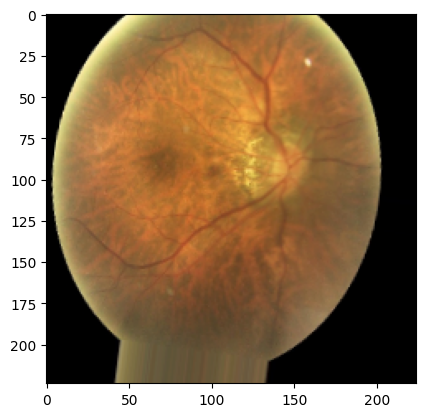

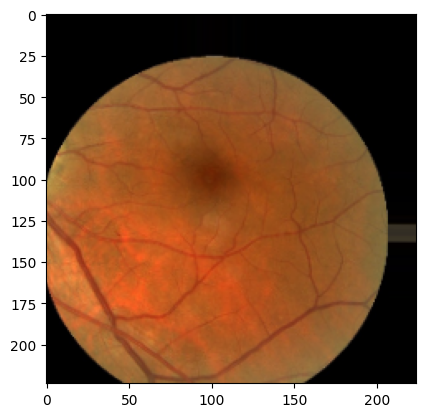

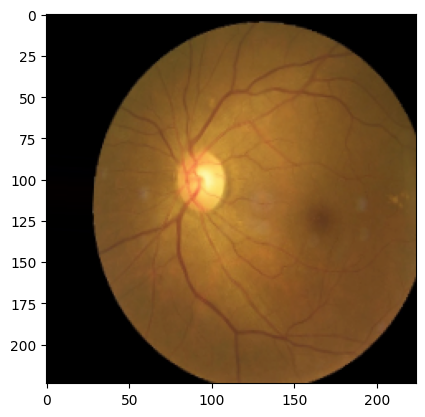

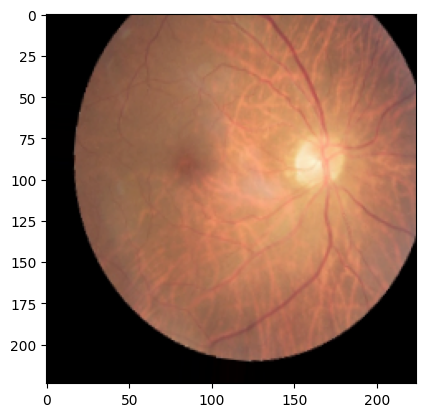

In [ ]:
from keras.preprocessing import image
i = 0
for batch in train_datagen.flow(X_train, y_train, batch_size=1):
  plt.figure(i)
  imgplot = plt.imshow(image.array_to_img(batch[0][0]))
  i += 1
  if i % 4 == 0:
    break
plt.show()

## Create Model

## Create Model using transfer learning

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19


In [ ]:
vgg = VGG19(weights="imagenet", include_top = False, input_shape=(224, 224, 3))

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
vgg.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in vgg.layers:
    layer.trainable = False

In [ ]:
# Descongelar parcialmente
for layer in vgg.layers[-4:]:
    layer.trainable = True

## Model Instance

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense, Dropout, GlobalAveragePooling2D
model = Sequential()
model.add(vgg)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense, Dropout, GlobalAveragePooling2D
model = Sequential()
model.add(vgg)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu", kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,172,225 (76.95 MB)

 Trainable params: 7,227,265 (27.57 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

In [ ]:
#compile model
opt = Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
model.compile(optimizer=opt,loss="binary_crossentropy",metrics=["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
#metric = 'accuracy'
metric = 'val_loss'
checkpoint = ModelCheckpoint("vgg19.h5", monitor = metric, verbose=1, save_best_only=True, save_weights_only=False, save_freq=1)
earlystop = EarlyStopping(monitor = metric, patience=5, verbose=1)
import math
steps_per_epoch = math.ceil(len(X_train) / 32)
validation_steps = math.ceil(len(X_test) / 32)

## Model fit

In [ ]:
# fit model
#history = model.fit(train_generator, epochs=30, validation_data=validation_generator, callbacks=[checkpoint, earlystop])
history = model.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=20, validation_data=validation_generator, validation_steps=validation_steps, callbacks=[earlystop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6369 - loss: 1.1162 - val_accuracy: 0.7600 - val_loss: 0.9883
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 535ms/step - accuracy: 0.6960 - loss: 1.0351 - val_accuracy: 0.7600 - val_loss: 0.9769
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 545ms/step - accuracy: 0.6775 - loss: 1.0406 - val_accuracy: 0.7600 - val_loss: 0.9552
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 543ms/step - accuracy: 0.6677 - loss: 1.0138 - val_accuracy: 0.7600 - val_loss: 0.9214
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 543ms/step - accuracy: 0.7076 - loss: 0.9654 - val_accuracy: 0.7600 - val_loss: 0.9026
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 542ms/step - accuracy: 0.6973 - loss: 0.9763 - val_accuracy: 0.7600 - val_loss: 0.9019
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 783ms/step - accuracy: 0.7128 - loss: 0.9188 - val_accuracy: 0.7250 - val_loss: 0.9545
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 518ms/step - accuracy: 0.6962 - loss: 0.9175 - val_accurac

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("loss:", loss)
print("Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 280ms/step - accuracy: 0.7567 - loss: 21.5201
loss: 21.465681076049805
Accuracy: 0.7649999856948853


In [ ]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


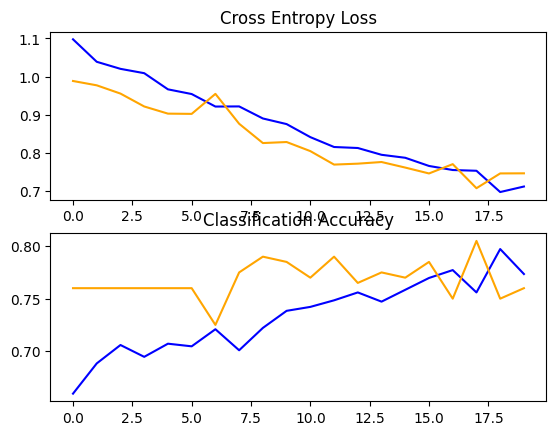

In [ ]:
from matplotlib import pyplot
import sys
summarize_diagnostics(history)

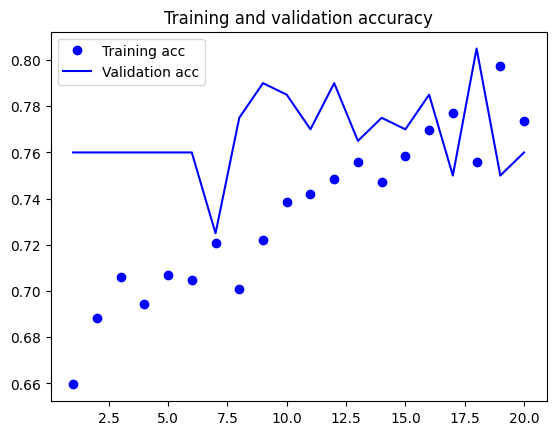

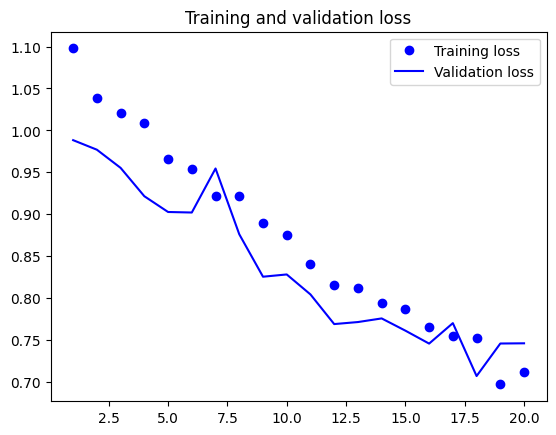

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
  # summarize model performance
def summarize_performance_kpi(true, pred, target_names):
    #Clasification report
    clf_report = classification_report(true,
                                        pred,
                                        labels=np.arange(2),
                                        target_names=target_names,
                                        output_dict=True)
    print('\n\n')
    pyplot.figure(figsize=(8, 6))
    ax = pyplot.axes()
    sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
    ax.set_title('Clasification Report')
    pyplot.show()
    print('\n\n')
    # Confusion Matrix
    cm = confusion_matrix(true, pred)
    plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=False)

In [ ]:
import numpy as np


def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

In [ ]:
model.save('AMD_detection.h5')